# Test different ML models of UTCI

To build an emulator of the Fiala-UTCI model, we want to first check which regression method is likely to be the most appropriate. For this reason, we build four representational models using five methods commonly used to adress this type of regression problem: 

- 6th order polynomial regression. This is what is currently used in the literature opperationally. 
- Support Vector Regression
- Random Forest Regression
- XGBoost
- Neural Network

We build models that are representitive by selecting initial archetectures and tuning parameters that are typical and reasonable for the problem. This is done by expert judegement. Where these models overfit the data, we increase regularisation, and tune the hyperparametrs to  the best of our abilty but we do not conduct a grid search for the optimal hyperparameters. It is out of the scope of this study to do a detailed comparison of methods, rather the aim is a baseline understanding of the best method for the problem and justifying our selction of method. 

### Representational Model Comparison

##### Set up

In [ ]:
# =========================
# Core scientific stack
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# =========================
# Scikit-learn
# =========================
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    max_error,
)

# =========================
# XGBoost
# =========================
import xgboost as xgb
from xgboost import XGBRegressor

# =========================
# Optuna & utilities
# =========================
import optuna
import joblib
import logging
import math
import time

# =========================
# PyTorch (ANN)
# =========================
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


c:\Users\nerc-user\.conda\envs\utci\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Data
esm4 = pd.read_csv(rf'..\data\ESM_4_Table_Offset.DAT' , sep='\t', comment='*')
test_fiala = df = pd.read_csv(rf'..\data\UTCI-Test-Data.txt', sep='\t', comment='#')

In [3]:
# Add a 'Tr' column to both datasets
esm4['Tr'] = esm4['Tr-Ta'] + esm4['Ta']
test_fiala['Tr'] = test_fiala['Tr-Ta'] + test_fiala['Ta']

## Split the data

In [4]:
# Split the data
train_x, val_x, train_y, val_y = train_test_split(esm4[['Ta', 'Tr', 'va', 'pa']], esm4['Offset'], test_size=0.1, random_state=40)

test_x, test_y = test_fiala[['Ta', 'Tr', 'va', 'pa']], test_fiala['Offset']

In [5]:
# ---------- Step 0: Preprocessing pipeline for NUMERIC-ONLY data ----------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# Your numeric feature columns:
numeric_features = ['Ta', 'Tr', 'va', 'pa']

# Numeric pipeline: impute + scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer (no categorical pipeline needed)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features)
    ],
    remainder='drop'
)

# Fit on training data ONLY
preprocessor.fit(train_x)

# Transform train/val/test
X_train_proc = preprocessor.transform(train_x)
X_val_proc   = preprocessor.transform(val_x)
X_test_proc  = preprocessor.transform(test_x)

print("Processed shapes:")
print("Train:", X_train_proc.shape)
print("Val:",   X_val_proc.shape)
print("Test:",  X_test_proc.shape)

# Optional: look at first few processed samples
pd.DataFrame(X_train_proc, columns=numeric_features).head()

# Save preprocessor for reproducibility
joblib.dump(preprocessor, "preprocessor_numeric_only.joblib")
print("Saved preprocessor to preprocessor_numeric_only.joblib")


Processed shapes:
Train: (94178, 4)
Val: (10465, 4)
Test: (1000, 4)
Saved preprocessor to preprocessor_numeric_only.joblib


##### Prepare evaluation metrics
The models are evaluated by Root Mean Square Error (RMSE), Mean Error (ME), Mean Absolute Error (MAE), and Maximum Error (Maxerr)

In [6]:
# Define custom evaluation function
def evaluate_all(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    me = np.mean(y_pred - y_true)
    mae = mean_absolute_error(y_true, y_pred)
    maxerr = max_error(y_true, y_pred)
    return rmse, me, mae, maxerr


In [7]:
# Set up data storage for results

# Dictionary to collect results
results = {}

# Dataframe to save the testing UTCI predictions
test_fiala_model_results = test_fiala.copy()

##### Run the representitive models

### Polynomial Regression

In [ ]:
### Polynomial Regression ###
# As used in the legacy opperational procedure

# Polynomial regression with degree 6
poly_model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=6), LinearRegression())
poly_model.fit(train_x, train_y)
poly_train_preds = poly_model.predict(train_x)
poly_val_preds = poly_model.predict(val_x)
poly_test_preds = poly_model.predict(test_x)

# Save errors in the test dataframe
test_fiala_model_results['error_Poly'] = test_y - poly_test_preds

# Save evaluations
results['PolyDeg6_Linear_train'] = evaluate_all(train_y, poly_train_preds)
results['PolyDeg6_Linear_val'] = evaluate_all(val_y, poly_val_preds)
results['PolyDeg6_Linear_test'] = evaluate_all(test_y, poly_test_preds)

In [9]:
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_31072\2675069330.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  pipeline.fit(train_x, train_y.ravel())
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_31072\2675069330.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  pipeline.fit(train_x, train_y.ravel())
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_31072\2675069330.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  pipeline.fit(train_x, train_y.ravel())
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_31072\2675069330.py:72: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not

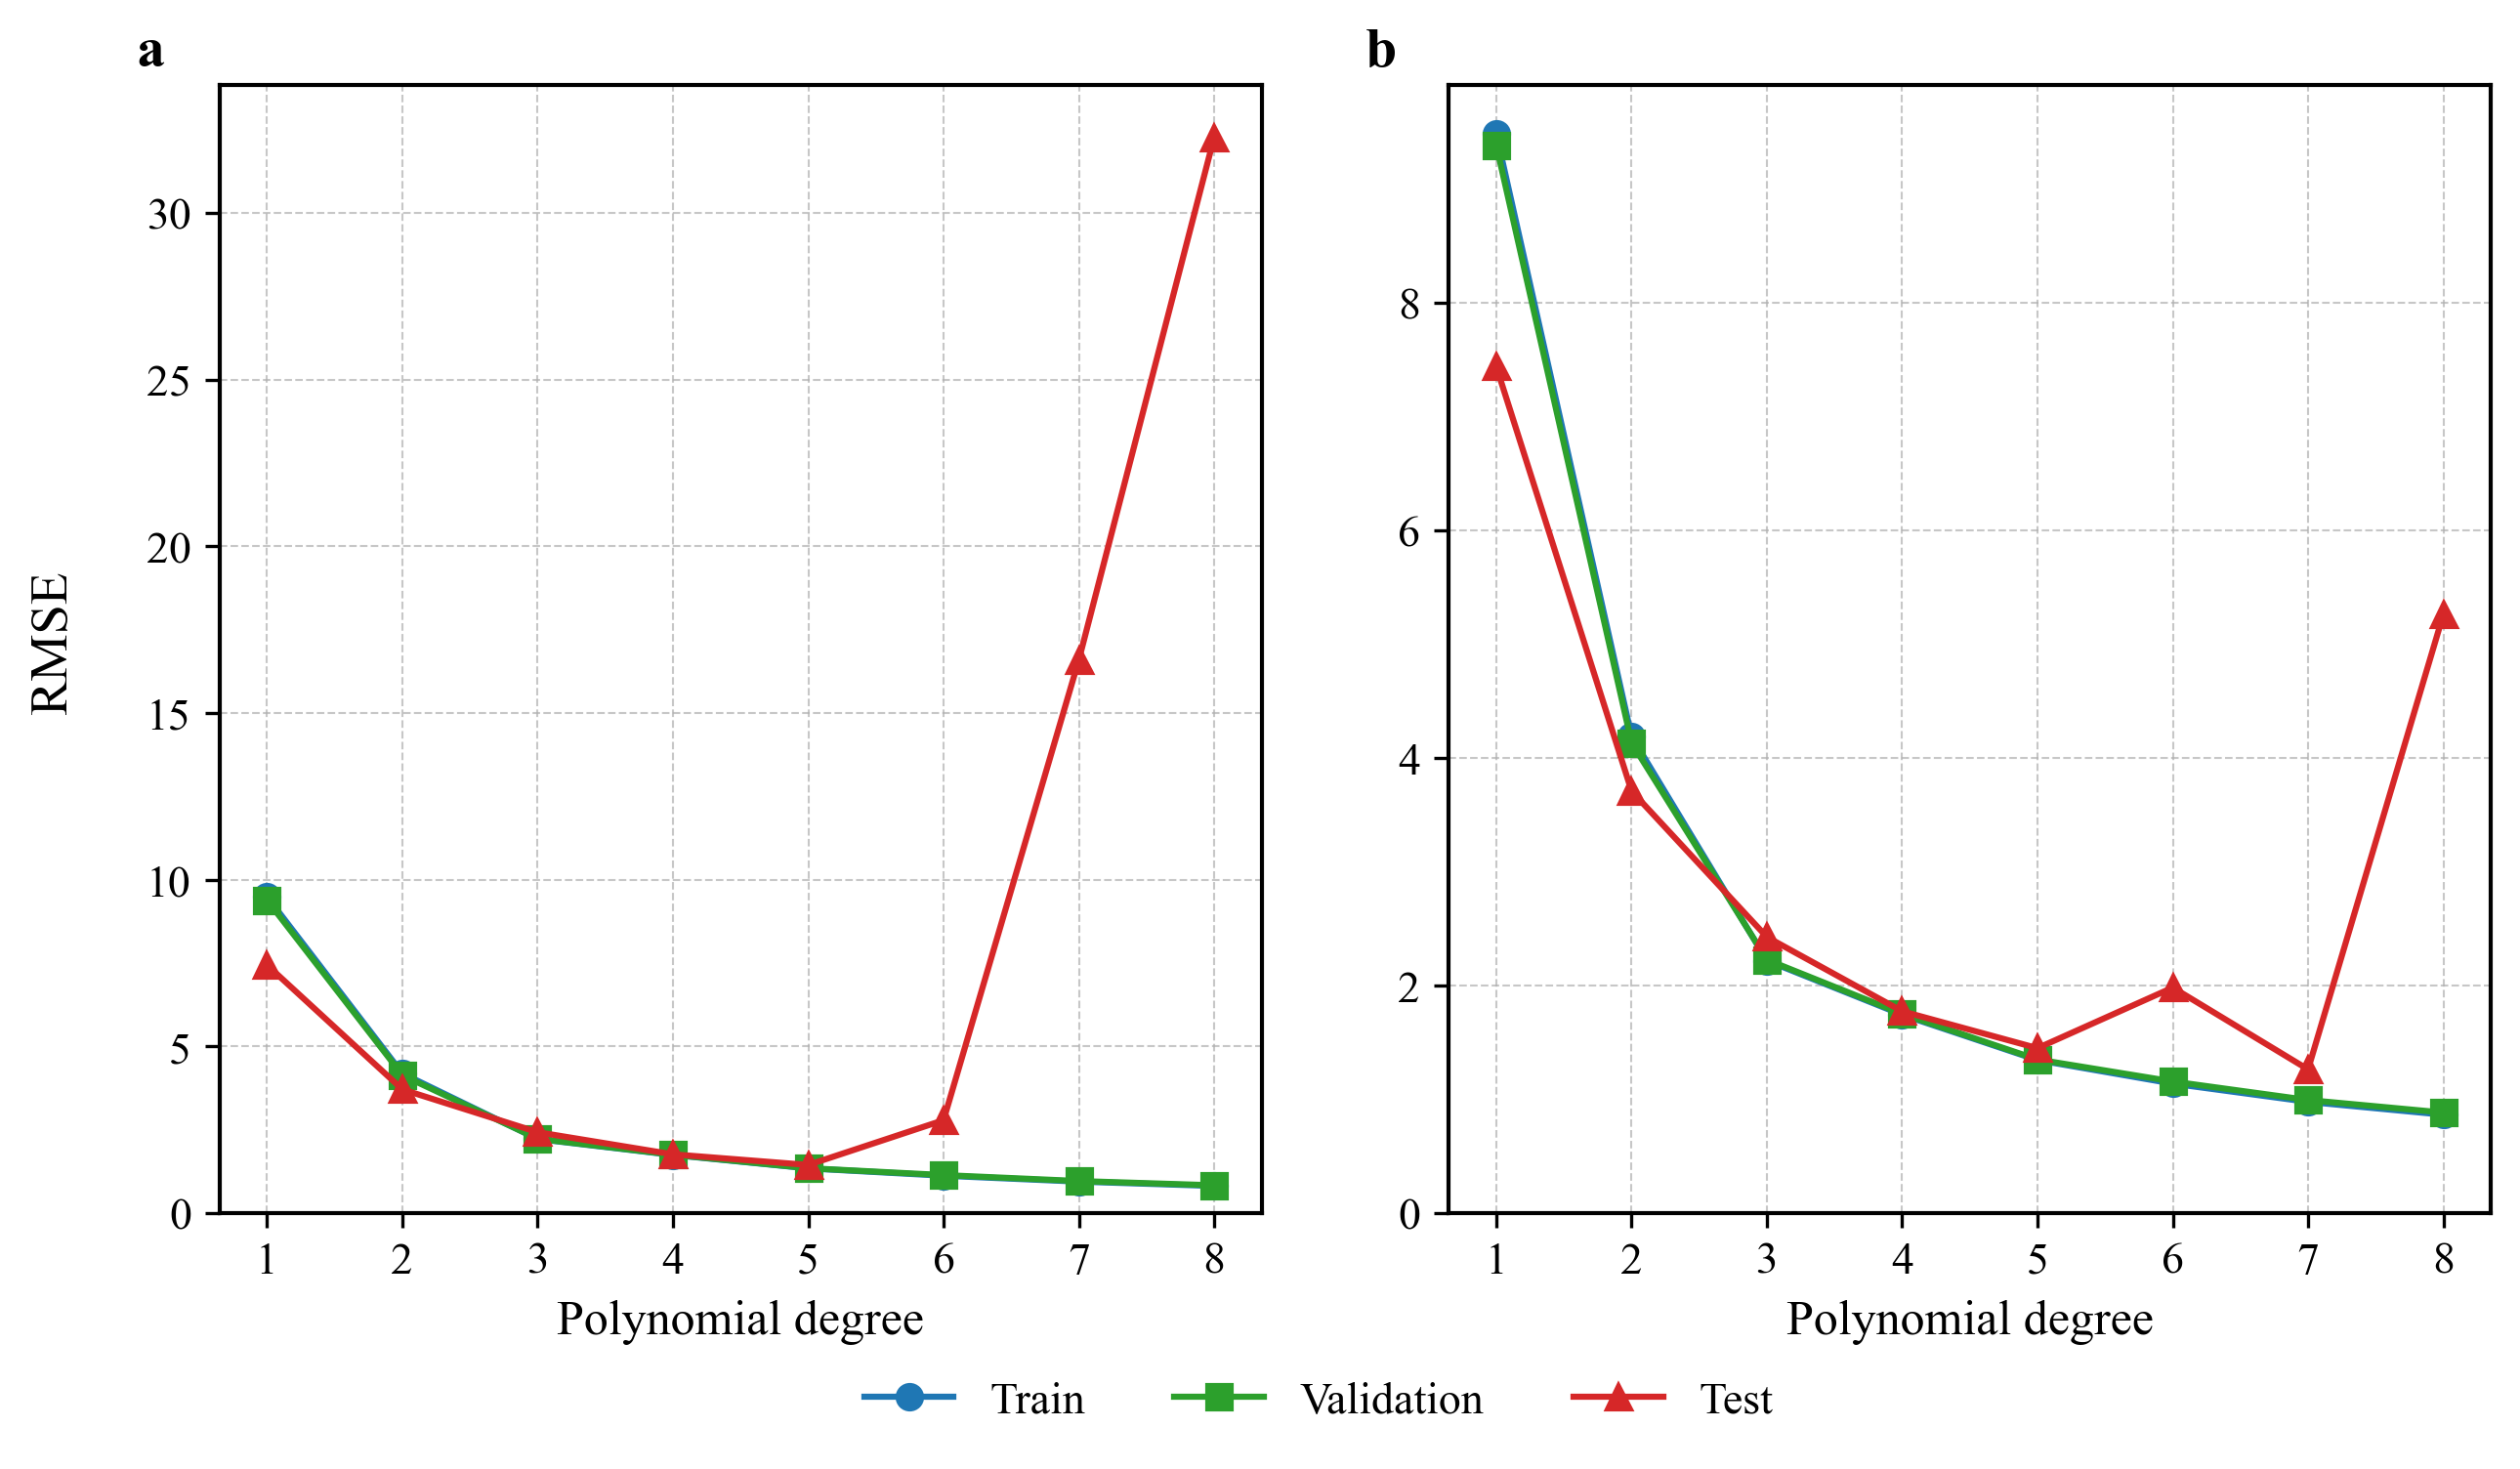

In [ ]:
# --- Publication-quality rc settings (consistent + larger text) ---
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# --- Configuration (degrees & models) ---
degrees = list(range(1, 9))
models = [
    ('OLS', LinearRegression, {}),         # ordinary least squares
    ('Ridge', Ridge, {'alpha': 10})        # ridge
]

# --- Prepare results container ---
results = {}
# We'll also collect legend handles once
legend_handles = None

# --- Create 2x2 subplot figure (top row: our two model plots; bottom row left/right reserved) ---
fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(1, 2, hspace=0.18, wspace=0.18)

# Top panels: polynomial RMSE comparisons (one per model)
ax_left = fig.add_subplot(gs[0, 0])   # OLS panel
ax_right = fig.add_subplot(gs[0, 1])  # Ridge panel, share y-axis visually #, sharey=ax_left

model_axes = [ax_left, ax_right]

# --- Plotting parameters (manuscript-friendly) ---
marker_kw = dict(ms=6)
line_kw = dict(linewidth=1.5)
colors = {'train': '#1f77b4', 'val': '#2ca02c', 'test': '#d62728'}

# --- Loop through models and fill the top-row axes ---
for ax, (name, model_cls, m_kwargs) in zip(model_axes, models):
    train_errors = []
    val_errors = []
    test_errors = []

    for degree in degrees:
        pipeline = make_pipeline(
            StandardScaler(),
            PolynomialFeatures(degree, include_bias=False),
            model_cls(**(m_kwargs or {}))
        )
        # Fit (ensure shapes ok)
        pipeline.fit(train_x, train_y.ravel())

        # Predict
        train_pred = pipeline.predict(train_x)
        val_pred = pipeline.predict(val_x)
        test_pred = pipeline.predict(test_x)

        # Compute RMSEs
        train_rmse = root_mean_squared_error(train_y, train_pred)
        val_rmse = root_mean_squared_error(val_y, val_pred)
        test_rmse = root_mean_squared_error(test_y, test_pred)

        train_errors.append(train_rmse)
        val_errors.append(val_rmse)
        test_errors.append(test_rmse)


    # save results programmatically
    results[name] = {'degrees': degrees,
                     'train_rmse': train_errors,
                     'val_rmse': val_errors,
                     'test_rmse': test_errors}

    # Plot curves
    l1 = ax.plot(degrees, train_errors, marker='o', label='Train RMSE', color=colors['train'], **line_kw)
    l2 = ax.plot(degrees, val_errors,   marker='s', label='Validation RMSE', color=colors['val'], **line_kw)
    l3 = ax.plot(degrees, test_errors,  marker='^', label='Test RMSE', color=colors['test'], **line_kw)

    # Collect legend handles once (use the Line2D objects from the first axis)
    if legend_handles is None:
        # l1, l2, l3 are lists of Line2D; combine them
        legend_handles = [l1[0], l2[0], l3[0]]

    # Axis formatting (matches style in your big example)
    ax.set_xlabel('Polynomial degree', fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xticks(degrees)
    ax.set_ylim(bottom=0)

# --- Shared Y-axis label (placed on figure, left side like your example) ---
fig.text(0.06, 0.5, 'RMSE', va='center', rotation='vertical', fontsize=13)

# --- Shared legend below the top panels (matching your example's placement style) ---
fig.legend(
    legend_handles,
    ['Train', 'Validation', 'Test'],
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.06)
)

# --- Panel labels like in your example ('a', 'b') placed in each top panel ---
panel_labels = ['a', 'b']
for idx, ax in enumerate(model_axes):
    ax.text(-0.08, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# --- Tidy layout, leave space for legend below ---
plt.tight_layout(rect=[0, 0, 0.92, 1.0])

# --- SAVE FIGURE FOR MANUSCRIPT (PNG/PDF/EPS) ---
out_base = '../results/supplementary/polynomial_models_comparison'
fig.savefig(out_base + '.png', dpi=600, bbox_inches='tight', pad_inches=0.01)
fig.savefig(out_base + '.pdf', bbox_inches='tight', pad_inches=0.01)
fig.savefig(out_base + '.eps', bbox_inches='tight', pad_inches=0.01)

plt.show()


A - Ordinary Least Squares Regression, Train and Validation are similar to one another, but Test data decouples from performance at 6th order. 

B - Ridge regularised regression (alpha =10)

## Support Vector Regression

In [33]:
### Support Vector Regression (SVR) ###
svm_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01, max_iter=1000))
svm_model.fit(train_x, train_y)

svm_train_preds = svm_model.predict(train_x)
svm_val_preds = svm_model.predict(val_x)
svm_test_preds = svm_model.predict(test_x)

# Save errors in the test dataframe
test_fiala_model_results['error_SVR'] = test_y - svm_test_preds

# Save evaluations
results['SVR_train'] = evaluate_all(train_y, svm_train_preds)
results['SVR_val'] = evaluate_all(val_y, svm_val_preds)
results['SVR_test'] = evaluate_all(test_y, svm_test_preds)

c:\Users\nerc-user\.conda\envs\utci\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
# ---------- Optuna tuning for SVR (final model = TRAIN ONLY) ----------
import optuna
import joblib
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

# ---------- Settings ----------
N_TRIALS = 50
RANDOM_SEED = 42
# If SUBSAMPLE_SIZE is None => use full training set for trials (slow).
# Recommended: 10k-30k for 100k-row dataset to speed up SVR tuning.
SUBSAMPLE_SIZE = None
VERBOSE = False
FALLBACK_MAX_ITER = -1  # -1 => no limit; sklearn SVR accepts -1

rng = np.random.RandomState(RANDOM_SEED)

def svr_objective(trial):
    # 1) sample hyperparameters
    C = trial.suggest_float("C", 1e-2, 1e3, log=True)
    gamma_kind = trial.suggest_categorical("gamma_kind", ["scale", "auto", "float"])
    if gamma_kind == "float":
        gamma = trial.suggest_float("gamma_val", 1e-6, 1e1, log=True)
    else:
        gamma = gamma_kind
    epsilon = trial.suggest_float("epsilon", 1e-6, 1e-2, log=True)
    max_iter = trial.suggest_categorical("max_iter", [1000, 5000, -1])

    # 2) build model (RBF kernel)
    model = SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon, max_iter=max_iter)

    # 3) subsample train for speed (optional)
    if SUBSAMPLE_SIZE is None or SUBSAMPLE_SIZE >= X_train_proc.shape[0]:
        X_sub = X_train_proc
        y_sub = train_y
    else:
        # use sklearn.utils.resample to preserve dtype and shapes
        X_sub, y_sub = resample(X_train_proc, train_y, n_samples=SUBSAMPLE_SIZE, random_state=rng)

    # 4) fit on subsample
    model.fit(X_sub, y_sub)

    # 5) evaluate on full validation set (objective)
    val_preds = model.predict(X_val_proc)
    rmse = np.sqrt(mean_squared_error(val_y, val_preds))

    # optional: report intermediate rmse to optuna (not using pruning here)
    trial.set_user_attr("trial_val_rmse", float(rmse))
    return float(rmse)

# ---------- Run the study ----------
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_svr.optimize(svr_objective, n_trials=N_TRIALS)

print("SVR best trial params:", study_svr.best_trial.params)
print("SVR best validation RMSE (trial):", study_svr.best_value)
print("SVR best trial attrs:", study_svr.best_trial.user_attrs)

# ---------- Build final SVR trained on TRAIN ONLY (no val during final fit) ----------
best = study_svr.best_trial.params.copy()
# translate gamma param
if best.get("gamma_kind") == "float":
    gamma_val = best.get("gamma_val")
else:
    gamma_val = best.get("gamma_kind")

final_max_iter = best.get("max_iter", FALLBACK_MAX_ITER)
final_C = best.get("C", 1.0)
final_epsilon = best.get("epsilon", 1e-3)

final_svr = SVR(kernel="rbf", C=final_C, gamma=gamma_val, epsilon=final_epsilon, max_iter=final_max_iter)

# Fit final model on TRAIN ONLY (this may be slow on large datasets)
final_svr.fit(X_train_proc, train_y)

# ---------- Predictions & evaluation ----------
svm_train_preds = final_svr.predict(X_train_proc)
svm_val_preds   = final_svr.predict(X_val_proc)
svm_test_preds  = final_svr.predict(X_test_proc)

# Save errors in the test dataframe
test_fiala_model_results['error_SVR'] = test_y - svm_test_preds

# Save evaluations using your evaluate_all function
results['SVR_train'] = evaluate_all(train_y, svm_train_preds)
results['SVR_val']   = evaluate_all(val_y,   svm_val_preds)
results['SVR_test']  = evaluate_all(test_y,  svm_test_preds)

# Persist final model and study
joblib.dump(final_svr, "final_svr_train_only.joblib")
joblib.dump(study_svr, "svr_optuna_study.joblib")
print("Saved final SVR to final_svr_train_only.joblib and study to svr_optuna_study.joblib")


[I 2025-12-08 01:09:13,022] A new study created in memory with name: no-name-a634a0d5-4762-4002-b62d-182d13f1dcc0
[I 2025-12-08 01:15:36,178] Trial 0 finished with value: 1.1599374488790306 and parameters: {'C': 0.7459343285726545, 'gamma_kind': 'scale', 'epsilon': 4.2079886696066345e-06, 'max_iter': -1}. Best is trial 0 with value: 1.1599374488790306.
[I 2025-12-08 01:29:25,457] Trial 1 finished with value: 0.6653518692174646 and parameters: {'C': 10.129197956845726, 'gamma_kind': 'float', 'gamma_val': 0.6715811311069951, 'epsilon': 7.068974950624607e-06, 'max_iter': -1}. Best is trial 1 with value: 0.6653518692174646.
[I 2025-12-08 01:37:19,104] Trial 2 finished with value: 14.370410629277853 and parameters: {'C': 4.205156450913866, 'gamma_kind': 'float', 'gamma_val': 9.472334467618552e-06, 'epsilon': 1.4742753159914662e-05, 'max_iter': -1}. Best is trial 1 with value: 0.6653518692174646.
[I 2025-12-08 01:48:42,702] Trial 3 finished with value: 1.6172983945667856 and parameters: {'C'

SVR best trial params: {'C': 1.964650334774262, 'gamma_kind': 'float', 'gamma_val': 7.574938464530857, 'epsilon': 9.153952211738656e-06, 'max_iter': -1}
SVR best validation RMSE (trial): 0.44185900375893883
SVR best trial attrs: {'trial_val_rmse': 0.44185900375893883}
Saved final SVR to final_svr_train_only.joblib and study to svr_optuna_study.joblib


## Random Forest

In [15]:
### Random Forest ###
rf_model = RandomForestRegressor(n_estimators=100, 
                                 max_depth=10, 
                                 criterion='squared_error', 
                                 min_samples_leaf=5,
                                 max_features='sqrt', 
                                 bootstrap=True,
                                 random_state=42,
                                 n_jobs=-1)

rf_model.fit(train_x, train_y)

rf_train_preds = rf_model.predict(train_x)
rf_val_preds = rf_model.predict(val_x)
rf_test_preds = rf_model.predict(test_x)

# Save errors in the test dataframe
test_fiala_model_results['error_RF'] = test_y - rf_test_preds

# Save evaluations
results['RandomForest_train'] = evaluate_all(train_y, rf_train_preds)
results['RandomForest_val'] = evaluate_all(val_y, rf_val_preds)
results['RandomForest_test'] = evaluate_all(test_y, rf_test_preds)

In [82]:
# ---------- Optuna tuning for RandomForest (train/val during trials), final model = TRAIN ONLY ----------
import optuna
import joblib
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ---------- Settings ----------
N_TRIALS = 50
RANDOM_SEED = 42
VERBOSE = False  # If True, print some trial progress
FALLBACK_ESTIMATORS = 100

def rf_objective(trial):
    # sample hyperparameters
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 500]),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    }

    # build and fit model on TRAIN (do not include val here)
    model = RandomForestRegressor(**params)
    model.fit(X_train_proc, train_y)

    # evaluate on VAL
    val_preds = model.predict(X_val_proc)
    rmse = np.sqrt(mean_squared_error(val_y, val_preds))

    # store OOB score if available (useful for diagnostics)
    try:
        oob = model.oob_score_ if params.get('bootstrap', False) and hasattr(model, 'oob_score_') else None
    except Exception:
        oob = None
    trial.set_user_attr("oob_score", float(oob) if oob is not None else None)

    return float(rmse)

# ---------- Run the Optuna study ----------
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_rf.optimize(rf_objective, n_trials=N_TRIALS)

print("RF best trial params:", study_rf.best_trial.params)
print("RF best validation RMSE (trial):", study_rf.best_value)
print("RF best trial attrs:", study_rf.best_trial.user_attrs)

# ---------- Build final RandomForest trained on TRAIN ONLY (no val during final fit) ----------
best_params = study_rf.best_trial.params.copy()

# Ensure deterministic behavior and n_jobs
best_params.update({'random_state': RANDOM_SEED, 'n_jobs': -1})

# If n_estimators missing for any reason, fallback
if 'n_estimators' not in best_params or best_params['n_estimators'] is None:
    best_params['n_estimators'] = FALLBACK_ESTIMATORS

final_rf = RandomForestRegressor(**best_params)
final_rf.fit(X_train_proc, train_y)  # TRAIN ONLY

# ---------- Predictions & evaluation ----------
rf_train_preds = final_rf.predict(X_train_proc)
rf_val_preds   = final_rf.predict(X_val_proc)
rf_test_preds  = final_rf.predict(X_test_proc)

# Save errors in the test dataframe
test_fiala_model_results['error_RF'] = test_y - rf_test_preds

# Save evaluations using your evaluate_all function
results['RandomForest_train'] = evaluate_all(train_y, rf_train_preds)
results['RandomForest_val']   = evaluate_all(val_y,   rf_val_preds)
results['RandomForest_test']  = evaluate_all(test_y,  rf_test_preds)

# Persist final model and study
joblib.dump(final_rf, "final_rf_train_only.joblib")
joblib.dump(study_rf, "rf_optuna_study.joblib")
print("Saved final RandomForest to final_rf_train_only.joblib and study to rf_optuna_study.joblib")


[I 2025-12-08 12:06:33,131] A new study created in memory with name: no-name-a131adeb-cdb1-4094-8bd7-8c85c30a0a4c


[I 2025-12-08 12:06:34,645] Trial 0 finished with value: 0.5745968095450594 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.5745968095450594.
[I 2025-12-08 12:06:35,097] Trial 1 finished with value: 3.546591034084268 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.5745968095450594.
[I 2025-12-08 12:06:41,962] Trial 2 finished with value: 0.3867855966062966 and parameters: {'n_estimators': 500, 'max_depth': 17, 'min_samples_leaf': 2, 'min_samples_split': 11, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.3867855966062966.
[I 2025-12-08 12:06:44,014] Trial 3 finished with value: 2.52137261762633 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 15, 'max_features': N

RF best trial params: {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 7, 'max_features': 'log2', 'bootstrap': False}
RF best validation RMSE (trial): 0.35412702320822326
RF best trial attrs: {'oob_score': None}
Saved final RandomForest to final_rf_train_only.joblib and study to rf_optuna_study.joblib


## XGBoost

In [18]:
### XGBoost ###
xgb_model = XGBRegressor(n_estimators=100, 
                         max_depth = 3,
                         learning_rate=0.05,
                         alpha=1,
                         random_state=42, 
                         n_jobs=-1)

xgb_model.fit(train_x, train_y)

xgb_train_preds = xgb_model.predict(train_x)
xgb_val_preds = xgb_model.predict(val_x)
xgb_test_preds = xgb_model.predict(test_x)

# Save errors in the test dataframe
test_fiala_model_results['error_XGB'] = test_y - xgb_test_preds

# Save evaluations
results['XGBoost_train'] = evaluate_all(train_y, xgb_train_preds)
results['XGBoost_val'] = evaluate_all(val_y, xgb_val_preds)
results['XGBoost_test'] = evaluate_all(test_y, xgb_test_preds)

In [90]:
# SETTINGS
N_TRIALS = 50
RANDOM_SEED = 42
EARLY_STOPPING_ROUNDS = 50
VERBOSE = False  # True to show xgboost progress
FALLBACK_ESTIMATORS = 200

# Prepare DMatrix objects (these use your preprocessed arrays)
dtrain = xgb.DMatrix(X_train_proc, label=train_y)
dval   = xgb.DMatrix(X_val_proc,   label=val_y)
dtest  = xgb.DMatrix(X_test_proc,  label=test_y)

def xgb_objective(trial):
    # sample hyperparameters (map to xgboost parameter names)
    params = {
        'objective': 'reg:squarederror',
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'eta': trial.suggest_float('learning_rate', 1e-3, 3e-1, log=True),   # eta == learning_rate
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),   # L1
        'lambda': trial.suggest_float('reg_lambda', 0.0, 10.0), # L2
        'seed': RANDOM_SEED,
        'verbosity': 0
    }

    # large number of rounds; early stopping will cut it
    num_boost_round = 2000

    # train with early stopping on validation
    # xgboost.train accepts evals + early_stopping_rounds reliably
    evals = [(dtrain, 'train'), (dval, 'valid')]
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=VERBOSE
    )

    # best iteration from booster
    best_iter = None
    try:
        # many versions expose best_iteration
        if hasattr(bst, 'best_iteration') and bst.best_iteration is not None:
            best_iter = int(bst.best_iteration)
    except Exception:
        best_iter = None

    # store best_iteration for this trial
    trial.set_user_attr("best_iteration", best_iter)

    # compute validation RMSE using the best iteration
    try:
        # prefer using ntree_limit if available
        val_preds = bst.predict(dval, ntree_limit=best_iter + 1 if best_iter is not None else None)
    except TypeError:
        # fallback: predict without ntree_limit (will use full booster)
        val_preds = bst.predict(dval)
    rmse = np.sqrt(mean_squared_error(val_y, val_preds))
    return float(rmse)

# Run the Optuna study
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(xgb_objective, n_trials=N_TRIALS)

print("Best trial params:", study.best_trial.params)
print("Best validation RMSE (trial):", study.best_value)
print("Best trial attrs:", study.best_trial.user_attrs)

# ---------- Build final model trained ON TRAIN ONLY (no val during final fit) ----------
best_params = study.best_trial.params.copy()
# Map Optuna param names to xgboost names used in training
xgb_final_params = {
    'objective': 'reg:squarederror',
    'max_depth': best_params.get('max_depth', 3),
    'eta': best_params.get('learning_rate', 0.1),
    'subsample': best_params.get('subsample', 1.0),
    'colsample_bytree': best_params.get('colsample_bytree', 1.0),
    'alpha': best_params.get('reg_alpha', 0.0),
    'lambda': best_params.get('reg_lambda', 0.0),
    'seed': RANDOM_SEED,
    'verbosity': 0
}

best_iter = study.best_trial.user_attrs.get('best_iteration', None)
if best_iter:
    num_boost_round_final = int(best_iter)
else:
    num_boost_round_final = FALLBACK_ESTIMATORS

# Train final booster on TRAIN ONLY (no evaluation on val)
final_bst = xgb.train(
    xgb_final_params,
    dtrain,
    num_boost_round=num_boost_round_final,
    verbose_eval=VERBOSE
)

# ---------- Predictions & evaluation ----------
# predict on numpy arrays by using DMatrix objects
xgb_train_preds = final_bst.predict(dtrain)
xgb_val_preds   = final_bst.predict(dval)
xgb_test_preds  = final_bst.predict(dtest)

# Save errors in the test dataframe
test_fiala_model_results['error_XGB'] = test_y - xgb_test_preds

# Save evaluations using your evaluate_all function
results['XGBoost_train'] = evaluate_all(train_y, xgb_train_preds)
results['XGBoost_val']   = evaluate_all(val_y,   xgb_val_preds)
results['XGBoost_test']  = evaluate_all(test_y,  xgb_test_preds)

# Persist final booster and study
final_bst.save_model("final_xgb_train_only.json")   # saves booster in JSON (portable)
joblib.dump(study, "xgb_optuna_study.joblib")
print("Saved final booster to final_xgb_train_only.json and study to xgb_optuna_study.joblib")


[I 2025-12-08 15:21:56,323] A new study created in memory with name: no-name-a9903d42-7774-4c7e-8e5f-d2adaa8bb994
[I 2025-12-08 15:22:00,343] Trial 0 finished with value: 0.3336418619410385 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516848, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'reg_alpha': 1.5601864044243652, 'reg_lambda': 1.5599452033620265}. Best is trial 0 with value: 0.3336418619410385.
[I 2025-12-08 15:22:03,302] Trial 1 finished with value: 0.6740120531161878 and parameters: {'max_depth': 3, 'learning_rate': 0.13983740016490973, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227, 'reg_alpha': 0.20584494295802447, 'reg_lambda': 9.699098521619943}. Best is trial 0 with value: 0.3336418619410385.
[I 2025-12-08 15:22:08,687] Trial 2 finished with value: 3.2357323388926833 and parameters: {'max_depth': 7, 'learning_rate': 0.0033572967053517922, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549

Best trial params: {'max_depth': 8, 'learning_rate': 0.04922654292371888, 'subsample': 0.669130035338716, 'colsample_bytree': 0.9489030808487717, 'reg_alpha': 4.98594130746366, 'reg_lambda': 6.082324342850095}
Best validation RMSE (trial): 0.2744771561764064
Best trial attrs: {'best_iteration': 1999}
Saved final booster to final_xgb_train_only.json and study to xgb_optuna_study.joblib


## ANN

In [19]:
### Artificial Neural Network ###

ann_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 64),
                 activation='relu',
                 solver='adam',
                 max_iter=100,
                 learning_rate='adaptive',
                 alpha=0.001,
                 early_stopping=True,
                 random_state=42)
)
ann_model.fit(train_x, train_y)

ann_train_preds = ann_model.predict(train_x)
ann_val_preds = ann_model.predict(val_x)
ann_test_preds = ann_model.predict(test_x)

# Save errors in the test dataframe
test_fiala_model_results['error_ANN'] = test_y - ann_test_preds

# Save evaluations
results['ANN_train'] = evaluate_all(train_y, ann_train_preds)
results['ANN_val'] = evaluate_all(val_y, ann_val_preds)
results['ANN_test'] = evaluate_all(test_y, ann_test_preds)

In [45]:
# ---------- Settings ----------
N_TRIALS = 50
RANDOM_SEED = 42
VERBOSE = True  # set False to reduce epoch logging
EARLY_STOPPING_PATIENCE = 10
MAX_EPOCHS = 200
FALLBACK_EPOCHS = 100

# ---------- Logging setup ----------
logger = logging.getLogger("optuna_torch_ann")
logger.setLevel(logging.INFO)
if not logger.handlers:
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter = logging.Formatter("%(asctime)s — %(levelname)s — %(message)s")
    ch.setFormatter(formatter)
    logger.addHandler(ch)

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

# ---------- Reproducibility ----------
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ---------- Convert preprocessed numpy arrays to torch tensors ----------
# Assumes X_train_proc, X_val_proc, X_test_proc are numpy arrays (from Step 0)
X_tr = np.asarray(X_train_proc, dtype=np.float32)
X_val = np.asarray(X_val_proc, dtype=np.float32)
X_te = np.asarray(X_test_proc, dtype=np.float32)
y_tr = np.asarray(train_y, dtype=np.float32).reshape(-1, 1)
y_val = np.asarray(val_y, dtype=np.float32).reshape(-1, 1)
y_te = np.asarray(test_y, dtype=np.float32).reshape(-1, 1)

# ---------- Helper: build DataLoaders ----------
def get_dataloaders(batch_size):
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# ---------- Helper: simple feedforward model factory ----------
def build_model(input_dim, n_layers, n_units, dropout, activation_name):
    layers = []
    in_dim = input_dim
    activation = nn.ReLU if activation_name == "relu" else nn.Tanh
    for i in range(n_layers):
        layers.append(nn.Linear(in_dim, n_units))
        layers.append(activation())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_dim = n_units
    layers.append(nn.Linear(in_dim, 1))  # regression output
    model = nn.Sequential(*layers)
    return model

# ---------- Training function with early stopping on external val ----------
def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, max_epochs, patience, device, verbose=False):
    model = model.to(device)
    best_val_rmse = float("inf")
    best_epoch = 0
    best_state = None
    epochs_no_improve = 0
    history = {"train_rmse": [], "val_rmse": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        train_rmse = math.sqrt(np.mean(train_losses)) if len(train_losses) > 0 else 0.0

        # validation
        model.eval()
        val_preds = []
        val_trues = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                out = model(xb).cpu().numpy()
                val_preds.append(out)
                val_trues.append(yb.numpy())
        val_preds = np.vstack(val_preds) if val_preds else np.empty((0,1))
        val_trues = np.vstack(val_trues) if val_trues else np.empty((0,1))
        if val_preds.size and val_trues.size:
            val_rmse = float(np.sqrt(mean_squared_error(val_trues, val_preds)))
        else:
            val_rmse = float("inf")

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        if verbose:
            logger.info(f"Epoch {epoch:03d}: train_rmse={train_rmse:.5f}, val_rmse={val_rmse:.5f}")

        # early stopping logic
        if val_rmse + 1e-12 < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    logger.info(f"Early stopping at epoch {epoch}, best_epoch={best_epoch}, best_val_rmse={best_val_rmse:.5f}")
                break

    # load best weights back into model
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_epoch, best_val_rmse, history

# ---------- Optuna objective ----------
def ann_objective(trial):
    # Sample hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units = trial.suggest_int("n_units", 16, 256, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    patience = trial.suggest_int("patience", 5, EARLY_STOPPING_PATIENCE)

    input_dim = X_tr.shape[1]
    model = build_model(input_dim, n_layers, n_units, dropout, activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_loader, val_loader, _ = get_dataloaders(batch_size)

    logger.info(f"Trial {trial.number}: layers={n_layers}, units={n_units}, dropout={dropout:.3f}, lr={lr:.3g}, wd={weight_decay:.3g}, batch={batch_size}, act={activation}, patience={patience}")

    # Train with early stopping on external val
    model, best_epoch, best_val_rmse, history = train_and_evaluate(
        model, train_loader, val_loader, optimizer, criterion,
        MAX_EPOCHS, patience, device, verbose=VERBOSE
    )

    # Save important trial attributes
    trial.set_user_attr("best_epoch", int(best_epoch))
    trial.set_user_attr("best_val_rmse", float(best_val_rmse))
    trial.set_user_attr("history", history)

    logger.info(f"Trial {trial.number} finished: best_epoch={best_epoch}, best_val_rmse={best_val_rmse:.5f}")

    return float(best_val_rmse)

# ---------- Run the Optuna study ----------
study_ann = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_ann.optimize(ann_objective, n_trials=N_TRIALS)

logger.info(f"Best ANN trial #{study_ann.best_trial.number}: params={study_ann.best_trial.params}, val_rmse={study_ann.best_value:.5f}, attrs={study_ann.best_trial.user_attrs}")

# ---------- Build final model trained on TRAIN ONLY (no val during final fit) ----------
best = study_ann.best_trial
best_params = best.params
n_layers = best_params.get("n_layers", 1)
n_units = best_params.get("n_units", 64)
dropout = best_params.get("dropout", 0.0)
lr = best_params.get("lr", 1e-3)
weight_decay = best_params.get("weight_decay", 1e-4)
batch_size = best_params.get("batch_size", 128)
activation = best_params.get("activation", "relu")
best_epoch = best.user_attrs.get("best_epoch", None)

# If best_epoch found, use it as number of epochs; otherwise fallback
if best_epoch:
    final_epochs = int(best_epoch)
else:
    final_epochs = FALLBACK_EPOCHS

logger.info(f"Final ANN training on TRAIN ONLY for epochs={final_epochs} (from best trial)")

# Build final model and optimizer
final_model = build_model(X_tr.shape[1], n_layers, n_units, dropout, activation)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=lr, weight_decay=weight_decay)
final_criterion = nn.MSELoss()
train_loader, val_loader, test_loader = get_dataloaders(batch_size)

# Train final model on TRAIN ONLY for final_epochs (no early stopping, no val)
final_model = final_model.to(device)
final_model.train()
for epoch in range(1, final_epochs + 1):
    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        final_optimizer.zero_grad()
        preds = final_model(xb)
        loss = final_criterion(preds, yb)
        loss.backward()
        final_optimizer.step()
    if VERBOSE and (epoch % max(1, final_epochs // 10) == 0 or epoch == 1 or epoch == final_epochs):
        logger.info(f"[Final train] Epoch {epoch}/{final_epochs}")

# Move to eval and predict
final_model.eval()
def predict_numpy(model, X_np, device, batch_size=1024):
    ds = TensorDataset(torch.from_numpy(np.asarray(X_np, dtype=np.float32)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    preds = np.vstack(preds)
    return preds.ravel()  # return 1d array

ann_train_preds = predict_numpy(final_model, X_tr, device, batch_size)
ann_val_preds   = predict_numpy(final_model, X_val, device, batch_size)
ann_test_preds  = predict_numpy(final_model, X_te, device, batch_size)

# Save errors in the test dataframe
test_fiala_model_results['error_ANN'] = test_y - ann_test_preds

# Save evaluations using your evaluate_all function
results['ANN_train'] = evaluate_all(train_y, ann_train_preds)
results['ANN_val']   = evaluate_all(val_y,   ann_val_preds)
results['ANN_test']  = evaluate_all(test_y,  ann_test_preds)

# Persist final model and study
torch.save(final_model.state_dict(), "final_ann_torch_train_only.pth")
joblib.dump(study_ann, "ann_optuna_torch_study.joblib")
logger.info("Saved final ANN state dict to final_ann_torch_train_only.pth and study to ann_optuna_torch_study.joblib")


2025-12-07 21:56:05,473 — INFO — Using device: cpu
[I 2025-12-07 21:56:05,515] A new study created in memory with name: no-name-7de54db8-ea2e-4a0c-aa8d-c219ff75ca55
2025-12-07 21:56:09,139 — INFO — Trial 0: layers=2, units=223, dropout=0.366, lr=0.00158, wd=4.21e-06, batch=256, act=tanh, patience=5
2025-12-07 21:56:12,257 — INFO — Epoch 001: train_rmse=7.08476, val_rmse=2.15951
2025-12-07 21:56:16,094 — INFO — Epoch 002: train_rmse=3.41213, val_rmse=1.72425
2025-12-07 21:56:19,736 — INFO — Epoch 003: train_rmse=3.25371, val_rmse=1.62148
2025-12-07 21:56:23,425 — INFO — Epoch 004: train_rmse=3.17206, val_rmse=1.52947
2025-12-07 21:56:27,035 — INFO — Epoch 005: train_rmse=3.11482, val_rmse=1.55684
2025-12-07 21:56:30,649 — INFO — Epoch 006: train_rmse=3.07204, val_rmse=1.42765
2025-12-07 21:56:34,256 — INFO — Epoch 007: train_rmse=3.04835, val_rmse=1.41862
2025-12-07 21:56:38,226 — INFO — Epoch 008: train_rmse=3.01621, val_rmse=1.31708
2025-12-07 21:56:42,607 — INFO — Epoch 009: train_rm

##### Model Comparison

In [91]:
### Create results table ###
columns = ['RMSE', 'ME', 'MAE', 'MaxError']
performance_df = pd.DataFrame(results, index=columns).T
performance_df.to_csv('../results/ml_performance_results.csv', index=True)
print(performance_df.round(3))

                        RMSE     ME    MAE  MaxError
OLS                      NaN    NaN    NaN       NaN
Ridge                    NaN    NaN    NaN       NaN
PolyDeg6_Linear_train  1.119 -0.000  0.819     6.167
PolyDeg6_Linear_val    1.138 -0.010  0.831     6.167
PolyDeg6_Linear_test   2.784  0.342  1.340    20.029
SVR_train              0.374  0.001  0.195    11.648
SVR_val                0.442 -0.001  0.221    12.662
SVR_test               5.598  1.424  1.764    42.438
XGBoost_train          0.235  0.000  0.180     1.567
XGBoost_val            0.275  0.002  0.207     1.544
XGBoost_test           3.207  1.943  2.050    12.473
RandomForest_train     0.211  0.000  0.157     1.918
RandomForest_val       0.354 -0.006  0.264     2.327
RandomForest_test      1.911  0.558  1.340     8.637
ANN_train              0.489 -0.120  0.374     3.782
ANN_val                0.494 -0.125  0.381     3.345
ANN_test               0.555 -0.275  0.414     4.330


## Plot Performance Metrics

In [92]:
### Plot performance metrics ###

# Prepare the data
df_test = performance_df[performance_df.index.str.endswith('_test')].copy()
df_train = performance_df[performance_df.index.str.endswith('_train')].copy()
df_val = performance_df[performance_df.index.str.endswith('_val')].copy()


df_test['Model'] = df_test.index.str.replace('_test', '', regex=False)
df_train['Model'] = df_train.index.str.replace('_train', '', regex=False)
df_val['Model'] = df_val.index.str.replace('_val', '', regex=False)


df_test = df_test.set_index('Model')
df_train = df_train.set_index('Model')
df_val = df_val.set_index('Model')

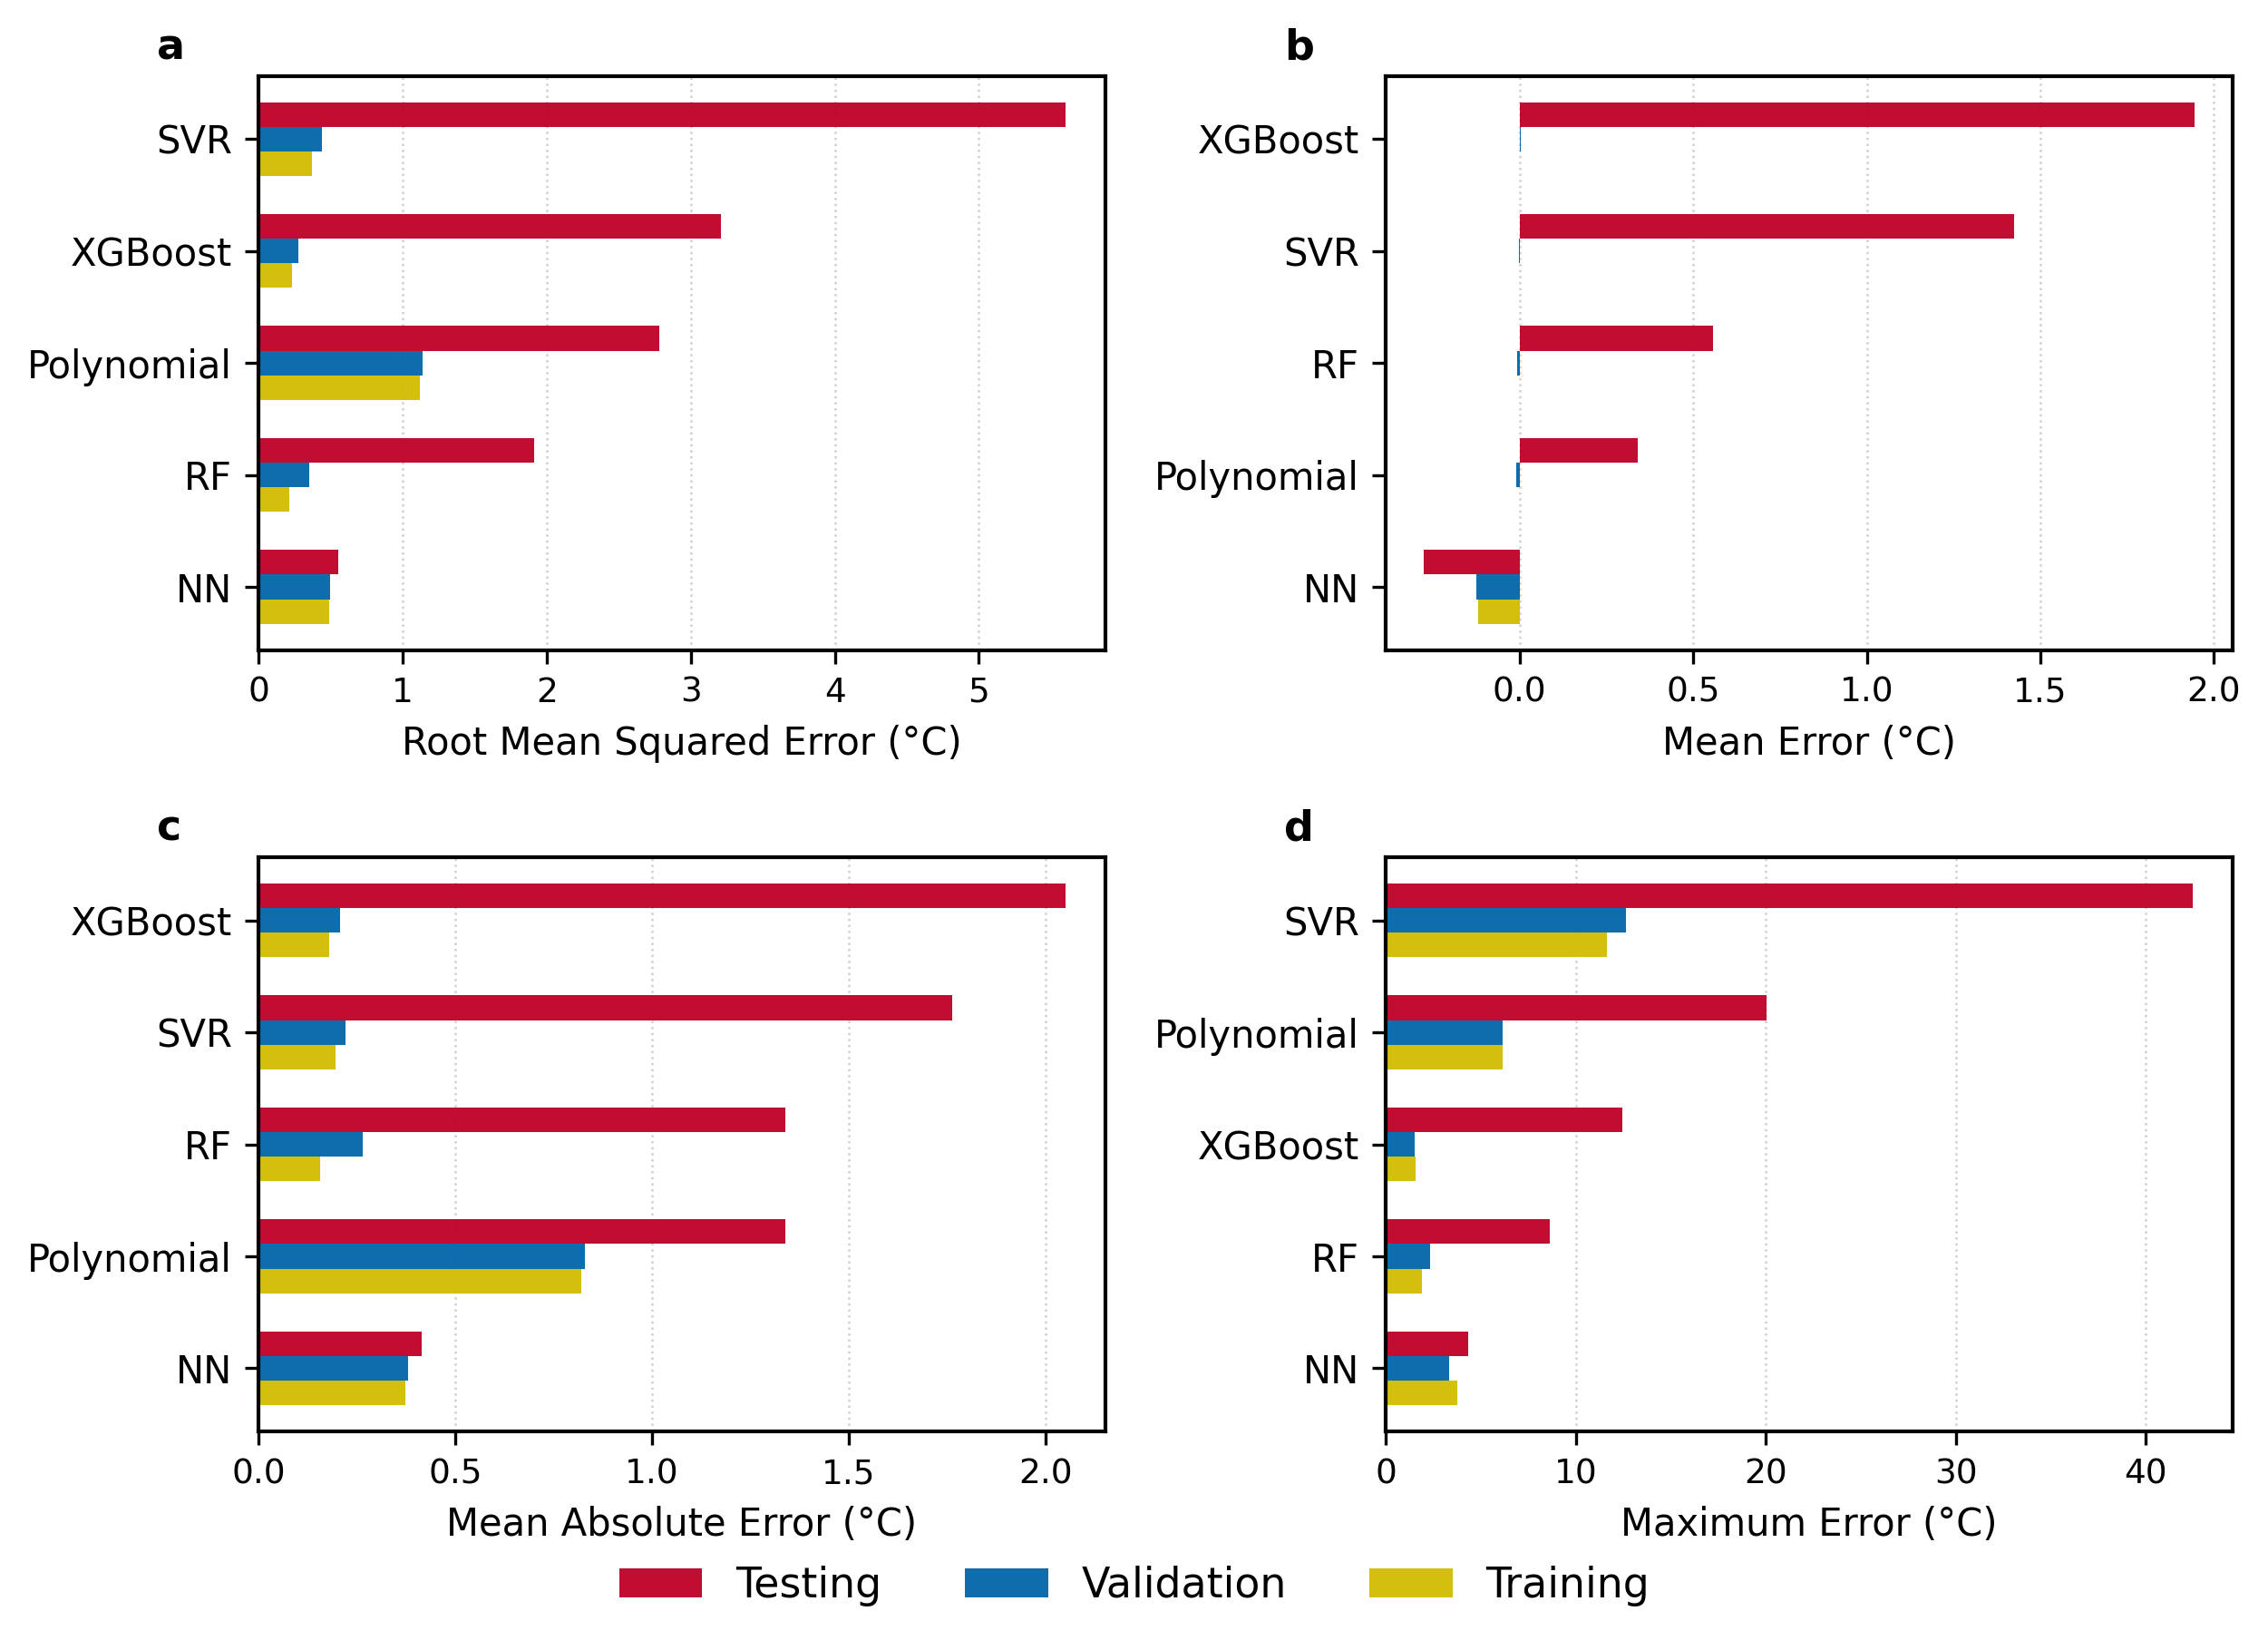

In [97]:
# Colors 
colors = {
    'train': '#D3BC00' ,  
    'val':   '#0065A9',  
    'test':  '#BD0026'  
}

metrics = ['RMSE', 'ME', 'MAE', 'MaxError']
xlabel_map = {
    'RMSE': 'Root Mean Squared Error (°C)',
    'ME': 'Mean Error (°C)',
    'MAE': 'Mean Absolute Error (°C)',
    'MaxError': 'Maximum Error (°C)'
}

fig, axes = plt.subplots(2, 2, figsize=(8.5, 6))
axes = axes.ravel()
plt.rcParams['font.family'] = 'DejaVu Sans'

for ax, metric, panel in zip(axes, metrics, ['a','b','c','d']):
    # choose order based on test (absolute for ME)
    if metric == 'ME':
        order = df_test[metric].abs().sort_values(ascending=False).index
    else:
        order = df_test[metric].sort_values(ascending=False).index

    n = len(order)
    y = np.arange(n)

    # get values in the same order
    test_vals = df_test.loc[order, metric].values
    val_vals  = df_val.loc[order, metric].values
    train_vals= df_train.loc[order, metric].values

    # bar width and offsets
    height = 0.22
    ax.barh(y - height, test_vals, height=height, color=colors['test'], label='Test', alpha=0.95)
    ax.barh(y,           val_vals,  height=height, color=colors['val'],  label='Val',  alpha=0.95)
    ax.barh(y + height, train_vals, height=height, color=colors['train'],label='Train', alpha=0.95)

    # y labels
    ax.set_yticks(y)
    ax.set_yticklabels(order.map({
        'PolyDeg6_Linear': 'Polynomial',
        'SVR': 'SVR',
        'RandomForest': 'RF',
        'XGBoost': 'XGBoost',
        'ANN': 'NN'
    }), fontsize=10)

    # labels and style
    ax.set_xlabel(xlabel_map[metric], fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', colors='black')
    ax.text(-0.12, 1.03, panel, transform=ax.transAxes, fontsize=11, fontweight='bold')


# legend and layout
fig.legend(['Testing','Validation','Training'], loc='lower center', ncol=3,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.subplots_adjust(bottom=0.11)
plt.savefig("../results/supplementary/model_comparison.png", dpi=600, bbox_inches='tight')
plt.show()


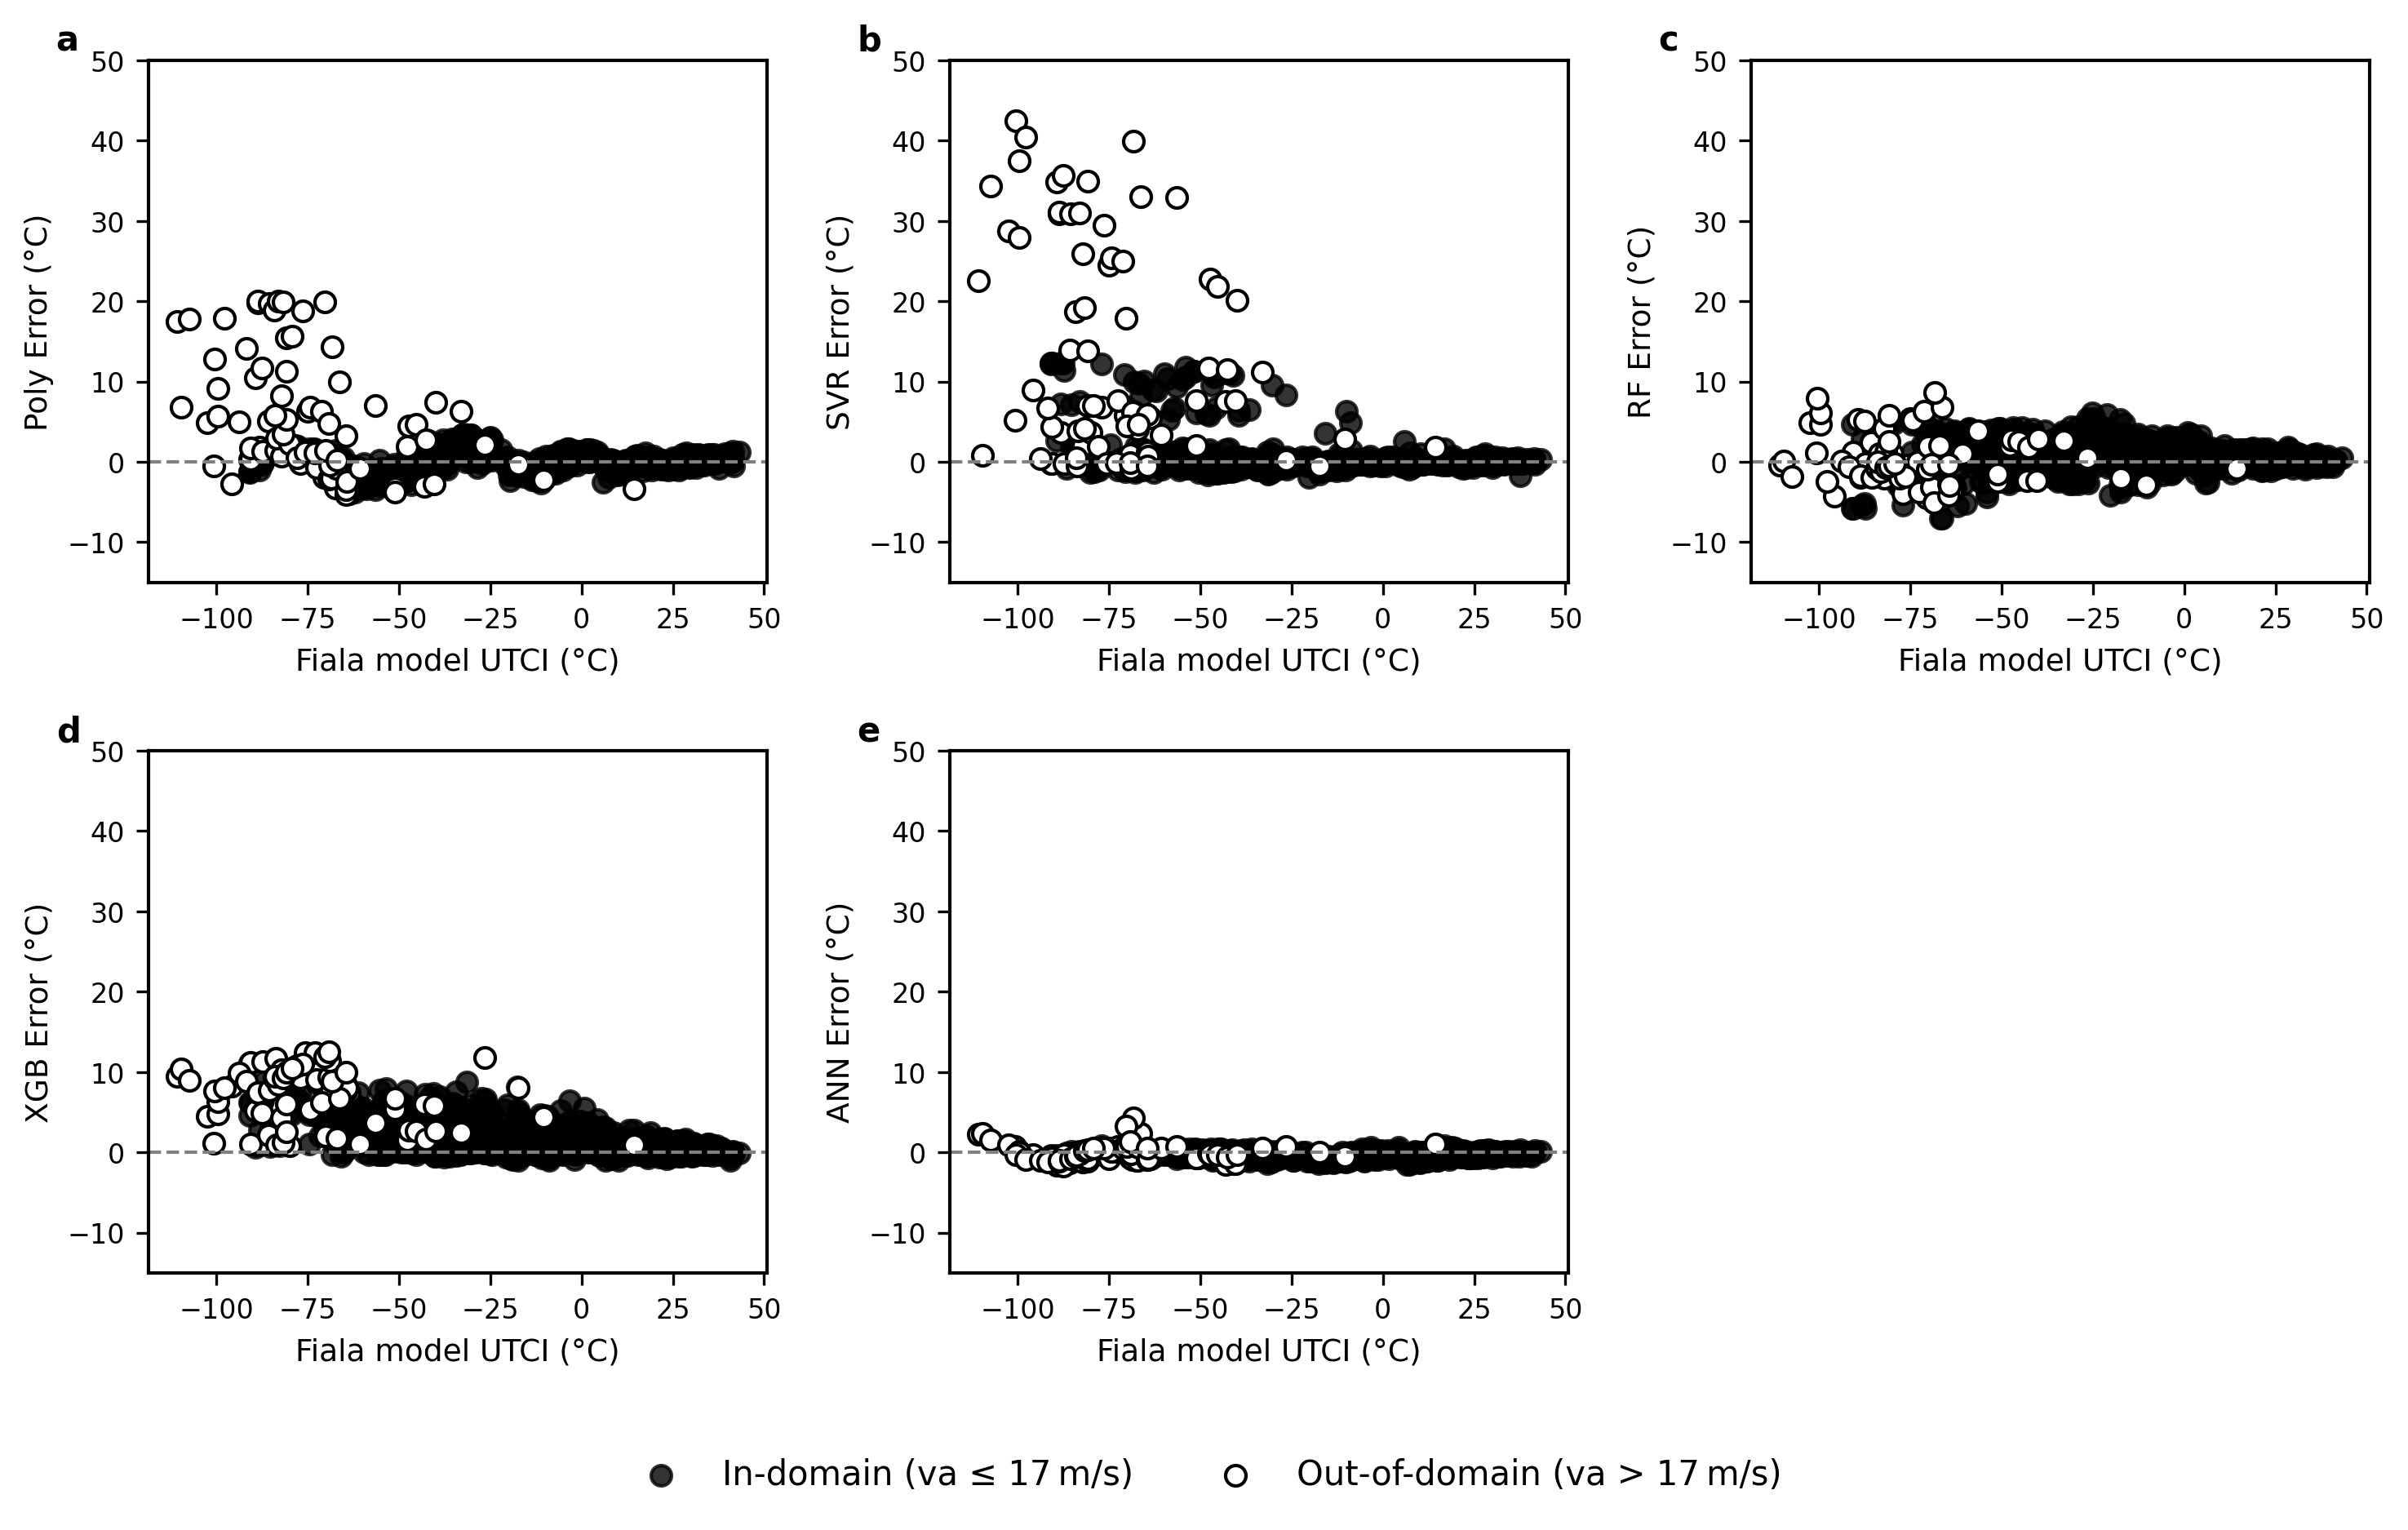

In [95]:
### Plot model performance on test data ###
# Mask for out-of-domain (wind speed > 17 m/s) 
nan_mask = test_fiala_model_results['va'] > 17  

# Setup plot 
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
axs = axs.flatten()

model_error_map = {
    'Poly': 'error_Poly',
    'SVR': 'error_SVR',
    'RF': 'error_RF',
    'XGB': 'error_XGB',
    'ANN': 'error_ANN'
}

panel_labels = ['a', 'b', 'c', 'd', 'e']

# Shared scatter settings
scatter_kwargs_in = dict(alpha=0.8, color='black', label='In-domain (va ≤ 17 m/s)')
scatter_kwargs_out = dict(facecolors='white', edgecolors='black', alpha=1, label='Out-of-domain (va > 17 m/s)')

for idx, (model_name, error_col) in enumerate(model_error_map.items()):
    ax = axs[idx]

    # Plot in-domain
    ax.scatter(test_fiala_model_results.loc[~nan_mask, 'UTCI'], -test_fiala_model_results.loc[~nan_mask, error_col], **scatter_kwargs_in)

    # Plot out-of-domain
    ax.scatter(test_fiala_model_results.loc[nan_mask, 'UTCI'], -test_fiala_model_results.loc[nan_mask, error_col], **scatter_kwargs_out)

    ax.set_xlabel('Fiala model UTCI (°C)', fontsize=9)
    ax.set_ylabel(f'{model_name} Error (°C)', fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim(-15, 50)
    ax.grid(False)
    ax.tick_params(labelsize=8)

    # Panel label
    ax.text(-0.15, 1.07, panel_labels[idx], transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top', ha='left')

# Turn off the empty 6th plot (bottom right)
if len(axs) > len(model_error_map):
    axs[-1].axis('off')

# Legend 
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # Space for legend

#plt.savefig("../results/ml_model_comparison/utci_representational_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
### Plot model performance on test data ###
# Mask for out-of-domain (wind speed > 17 m/s) 
nan_mask = test_fiala_model_results['va'] > 17  

# Setup plot 
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
axs = axs.flatten()

model_error_map = {
    'Poly': 'error_Poly',
    'SVR': 'error_SVR',
    'RF': 'error_RF',
    'XGB': 'error_XGB',
    'ANN': 'error_ANN'
}

panel_labels = ['a', 'b', 'c', 'd', 'e']

# Shared scatter settings
scatter_kwargs_in = dict(alpha=0.8, color='black', label='In-domain (va ≤ 17 m/s)')
scatter_kwargs_out = dict(facecolors='white', edgecolors='black', alpha=1, label='Out-of-domain (va > 17 m/s)')

for idx, (model_name, error_col) in enumerate(model_error_map.items()):
    ax = axs[idx]

    # Plot in-domain
    ax.scatter(test_fiala_model_results.loc[~nan_mask, 'UTCI'], -test_fiala_model_results.loc[~nan_mask, error_col], **scatter_kwargs_in)

    # Plot out-of-domain
    ax.scatter(test_fiala_model_results.loc[nan_mask, 'UTCI'], -test_fiala_model_results.loc[nan_mask, error_col], **scatter_kwargs_out)

    ax.set_xlabel('Fiala model UTCI (°C)', fontsize=9)
    ax.set_ylabel(f'{model_name} Error (°C)', fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim(-15, 22)
    ax.grid(False)
    ax.tick_params(labelsize=8)

    # Panel label
    ax.text(-0.15, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top', ha='left')

# Turn off the empty 6th plot (bottom right)
if len(axs) > len(model_error_map):
    axs[-1].axis('off')

# Legend 
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # Space for legend

#plt.savefig("../results/ml_model_comparison/utci_representational_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


### Representational Model Comparison Findings

The regression method comparison revealed that ANN is the best method out of the tested models to use for a UTCI emulator. The ANN acieved the lowest RMSE, MAE, and Maximum error on both the testing and training data. It produced the most uniform distribution of residuals across the range of Fiala UTCI values. While traditional models like Random Forest, XGBoost, and SVR were explored and tuned, they demonstrated either strong overfitting or underfitting behavior, making them less suitable as operational emulators for thermal comfort prediction. XGBoost overfit the training set, even with regularisation and parameter tuning. SVR had substantial test bias as measured by ME. Random Forest was more stable but suffered from test error despite tuning, and did not outperform ANN.

The Artificial Neural Network model was selected due to its superior generalization, low bias, and minimal error across all metrics. It proved particularly robust to both in-domain and out-of-domain inputs, and was the only model that did not suffer from significant overfitting or instability. Therefore, ANN is the most reliable and accurate model for predicting Fiala-adjusted UTCI under a wide range of environmental conditions.